In [2]:
import numpy as np
import pandas as pd
import scanpy as sc
import gc
import sys
import os
import sys
sys.path.append('/home/jovyan/notebooks_bidossessi/Inflammatory/Remapped/autoimmuneSC/AIID_notebooks/')

from inflapy.immunoFunc import *

##### E-MTAB-8322_Stefeno_2020

In [3]:
print(sc.__version__)

1.9.1


In [3]:
path="/lustre/scratch117/cellgen/cellgeni/TIC-starsolo/tic-1808/E-MTAB-8322/"

In [5]:
s_path = "/nfs/team205/bh14/Datasets/Remapped/raw_adata/"

In [5]:
os.listdir(path)

['ERS3741152',
 'starsolo_10x_auto.sh',
 'ERS3741162',
 'ERS3741176',
 'ERS3741157',
 'ERS3741158',
 'ERS3741172',
 'fixed_fastq',
 'ERS3741159',
 'ERS3741174',
 'solo_QC.sh',
 'fix_trimmed_fastq.sh',
 'ERS3741168',
 'ERS3741170',
 'bsub16.sh',
 'ERS3741161',
 'ERS3741164',
 'ERS3741169',
 'ERS3741153',
 'ERS3741155',
 'ERS3741151',
 'ERS3741173',
 'ERS3741166',
 'ERS3741167',
 'ERS3741175',
 'ERS3741163',
 'ERS3741154',
 'ERS3741177',
 'ERS3741156',
 'ERS3741160',
 'ERS3741165',
 'ERS3741171']

In [18]:
#GSE121380/GSM3433578/output/Velocyto/filtered/

pheno = pd.read_table(s_path+"E-MTAB-8322/E-MTAB-8322.sdrf.txt")

In [19]:
pheno.shape

(106, 80)

In [20]:
pheno = pheno.iloc[:,:17].drop_duplicates()

In [21]:
pheno.drop(columns = ['Characteristics[individual]', 'Material Type', 'Comment[BioSD_SAMPLE]',
       'Characteristics[organism]', 'Unit[time unit]', 'Term Source REF', 'Term Accession Number'], inplace=True)

In [23]:
pheno.shape

(27, 10)

In [24]:
pheno.columns = ['Donor_id', 'Sample_id', 'Age',
       'developmental_stage', 'Sex',
       'Disease', 'Response_treatment',
       'Tissue', 'Cell_source', 'Disease_status']

In [25]:
pheno.replace(["rheumatoid arthritis", "normal", "undifferentiated arthritis"],
                     ["Rheumatoid Arthritis", "Healthy", "Undifferentiated Arthritis"], inplace=True)

In [26]:
pheno.reset_index(inplace=True)

In [28]:
pheno.Disease.value_counts()

Rheumatoid Arthritis          19
Healthy                        4
Undifferentiated Arthritis     4
Name: Disease, dtype: int64

##### Immune compartment

In [29]:
for i in range(pheno.shape[0]):
    samp = pheno.Sample_id[i]
    print("Processing "+samp)
    adata = sc.read_10x_mtx(path+samp+"/output/Gene/filtered/")

    #adata.var[['ensembl', 'gene_symbol']]
    
    adata.obs["dataset_id"] = "E-MTAB-8322_Stefeno_2020"
    adata.obs["donor_id"] = pheno.Donor_id[i]+"_"+pheno.Sample_id[i]
    adata.obs["tissue"] = pheno.Tissue[i]
    adata.obs["cell_source"] = pheno.Cell_source[i]
    adata.obs["disease"] = pheno.Disease[i]
    adata.obs["disease_status"] = pheno.Disease_status[i]
    adata.obs["age"] = pheno.Age[i]
    adata.obs["sex"] = pheno.Sex[i]
    adata.obs["developmental_stage"] = pheno.developmental_stage[i]
    
    if 'adata_conc' in locals():
        adata.var_names_make_unique()
        adata_conc.var_names_make_unique()
        adata_conc = sc.concat([adata,adata_conc], index_unique="-")
        
    else:
        adata_conc = adata

    print(adata_conc.shape)

Processing ERS3741151
(1040, 36601)
Processing ERS3741152
(3096, 36601)
Processing ERS3741153
(5454, 36601)
Processing ERS3741154
(6424, 36601)
Processing ERS3741155
(8180, 36601)
Processing ERS3741156
(10269, 36601)
Processing ERS3741157
(10956, 36601)
Processing ERS3741158
(13487, 36601)
Processing ERS3741159
(25182, 36601)
Processing ERS3741160
(27301, 36601)
Processing ERS3741161
(28074, 36601)
Processing ERS3741162
(29256, 36601)
Processing ERS3741163
(30866, 36601)
Processing ERS3741164
(32845, 36601)
Processing ERS3741165
(36754, 36601)
Processing ERS3741166
(43436, 36601)
Processing ERS3741167
(45512, 36601)
Processing ERS3741168
(47303, 36601)
Processing ERS3741169
(48008, 36601)
Processing ERS3741170
(49412, 36601)
Processing ERS3741171
(50771, 36601)
Processing ERS3741172
(58101, 36601)
Processing ERS3741173
(64892, 36601)
Processing ERS3741174
(66511, 36601)
Processing ERS3741175
(74703, 36601)
Processing ERS3741176
(78064, 36601)
Processing ERS3741177
(80142, 36601)


In [30]:
adata_conc.obs

,dataset_id,donor_id,tissue,cell_source,disease,disease_status,age,sex,developmental_stage
AAACCTGCAAACCCAT-0,E-MTAB-8322_Stefeno_2020,SA153_ERS3741177,synovial membrane,macrophage,Undifferentiated Arthritis,Undifferentiated arthritis,62,female,adult
AAACCTGCAAGGTGTG-0,E-MTAB-8322_Stefeno_2020,SA153_ERS3741177,synovial membrane,macrophage,Undifferentiated Arthritis,Undifferentiated arthritis,62,female,adult
AAACCTGGTAGCGTGA-0,E-MTAB-8322_Stefeno_2020,SA153_ERS3741177,synovial membrane,macrophage,Undifferentiated Arthritis,Undifferentiated arthritis,62,female,adult
AAACCTGGTTGTACAC-0,E-MTAB-8322_Stefeno_2020,SA153_ERS3741177,synovial membrane,macrophage,Undifferentiated Arthritis,Undifferentiated arthritis,62,female,adult
AAACCTGTCGTACGGC-0,E-MTAB-8322_Stefeno_2020,SA153_ERS3741177,synovial membrane,macrophage,Undifferentiated Arthritis,Undifferentiated arthritis,62,female,adult
...,...,...,...,...,...,...,...,...,...
TTTGTCAAGCGATATA-1-1-1-1-1-1-1-1-1-1-1-1-1-1-1-1-1-1-1-1-1-1-1-1-1-1,E-MTAB-8322_Stefeno_2020,HC0547_ERS3741151,synovial membrane,macrophage,Healthy,Healthy control,24,male,adult
TTTGTCAAGTGTACGG-1-1-1-1-1-1-1-1-1-1-1-1-1-1-1-1-1-1-1-1-1-1-1-1-1-1,E-MTAB-8322_Stefeno_2020,HC0547_ERS3741151,synovial membrane,macrophage,Healthy,Healthy control,24,male,adult
TTTGTCACATACAGCT-1-1-1-1-1-1-1-1-1-1-1-1-1-1-1-1-1-1-1-1-1-1-1-1-1-1,E-MTAB-8322_Stefeno_2020,HC0547_ERS3741151,synovial membrane,macrophage,Healthy,Healthy control,24,male,adult
TTTGTCAGTAGGAGTC-1-1-1-1-1-1-1-1-1-1-1-1-1-1-1-1-1-1-1-1-1-1-1-1-1-1,E-MTAB-8322_Stefeno_2020,HC0547_ERS3741151,synovial membrane,macrophage,Healthy,Healthy control,24,male,adult


In [31]:
adata_conc.write_h5ad(s_path+"Immune_compartment_sorted_from_Tissue/E-MTAB-8322_Stefeno_2020.h5ad")

In [32]:
adata_conc.obs["disease"].value_counts()

Rheumatoid Arthritis          58468
Undifferentiated Arthritis    15250
Healthy                        6424
Name: disease, dtype: int64

##### Cell typist

In [10]:
adata = sc.read_h5ad("/nfs/team205/bh14/Datasets/Remapped/raw_adata/QC_Doublet/Immune_compartment_sorted_from_Tissue/E-MTAB-8322_Stefeno_2020.h5ad")

In [11]:
import celltypist
from celltypist import models


In [12]:
adata

AnnData object with n_obs × n_vars = 80142 × 36601
    obs: 'dataset_id', 'donor_id', 'tissue', 'cell_source', 'disease', 'disease_status', 'age', 'sex', 'developmental_stage', 'doublet_scores', 'predicted_doublets', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_rb', 'pct_counts_rb', 'QC'
    var: 'mt', 'rb', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'

In [14]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

In [15]:
adata.X.expm1().sum(axis = 1)

matrix([[10000.   ],
        [ 9999.999],
        [10000.   ],
        ...,
        [10000.   ],
        [10000.001],
        [10000.   ]], dtype=float32)

In [16]:
predictions = celltypist.annotate(adata, model = 'Immune_All_Low.pkl', majority_voting = True)

🔬 Input data has 80142 cells and 36601 genes
🔗 Matching reference genes in the model
🧬 6147 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
👀 Can not detect a neighborhood graph, will construct one before the over-clustering
⛓️ Over-clustering input data with resolution set to 20
🗳️ Majority voting the predictions
✅ Majority voting done!


In [17]:
predictions.predicted_labels

,predicted_labels,over_clustering,majority_voting
AAACCTGCAAACCCAT-0,Alveolar macrophages,185,Alveolar macrophages
AAACCTGCAAGGTGTG-0,Macrophages,173,Alveolar macrophages
AAACCTGGTAGCGTGA-0,Alveolar macrophages,170,Alveolar macrophages
AAACCTGGTTGTACAC-0,Alveolar macrophages,205,Intestinal macrophages
AAACCTGTCGTACGGC-0,Myelocytes,154,Alveolar macrophages
...,...,...,...
TTTGTCAAGCGATATA-1-1-1-1-1-1-1-1-1-1-1-1-1-1-1-1-1-1-1-1-1-1-1-1-1-1,Alveolar macrophages,116,Alveolar macrophages
TTTGTCAAGTGTACGG-1-1-1-1-1-1-1-1-1-1-1-1-1-1-1-1-1-1-1-1-1-1-1-1-1-1,Alveolar macrophages,100,Alveolar macrophages
TTTGTCACATACAGCT-1-1-1-1-1-1-1-1-1-1-1-1-1-1-1-1-1-1-1-1-1-1-1-1-1-1,Tcm/Naive helper T cells,83,Alveolar macrophages
TTTGTCAGTAGGAGTC-1-1-1-1-1-1-1-1-1-1-1-1-1-1-1-1-1-1-1-1-1-1-1-1-1-1,Intestinal macrophages,173,Alveolar macrophages


In [18]:
# Get an `AnnData` with predicted labels embedded into the cell metadata columns.
adata = predictions.to_adata()

In [19]:
adata

AnnData object with n_obs × n_vars = 80142 × 36601
    obs: 'dataset_id', 'donor_id', 'tissue', 'cell_source', 'disease', 'disease_status', 'age', 'sex', 'developmental_stage', 'doublet_scores', 'predicted_doublets', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_rb', 'pct_counts_rb', 'QC', 'predicted_labels', 'over_clustering', 'majority_voting', 'conf_score'
    var: 'mt', 'rb', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
    uns: 'log1p', 'neighbors', 'leiden'
    obsm: 'X_pca'
    obsp: 'connectivities', 'distances'

In [24]:
adata.obs[["majority_voting", "disease"]].value_counts().sort_index()

majority_voting              disease                   
Alveolar macrophages         Healthy                        5134
                             Rheumatoid Arthritis          20245
                             Undifferentiated Arthritis     5929
CD16+ NK cells               Rheumatoid Arthritis            375
                             Undifferentiated Arthritis       13
                                                           ...  
Tem/Temra cytotoxic T cells  Undifferentiated Arthritis       38
Tem/Trm cytotoxic T cells    Rheumatoid Arthritis           1431
                             Undifferentiated Arthritis      650
pDC                          Rheumatoid Arthritis            200
                             Undifferentiated Arthritis       18
Length: 63, dtype: int64

In [25]:
from plotnine import *

In [26]:
adata

AnnData object with n_obs × n_vars = 80142 × 36601
    obs: 'dataset_id', 'donor_id', 'tissue', 'cell_source', 'disease', 'disease_status', 'age', 'sex', 'developmental_stage', 'doublet_scores', 'predicted_doublets', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_rb', 'pct_counts_rb', 'QC', 'predicted_labels', 'over_clustering', 'majority_voting', 'conf_score'
    var: 'mt', 'rb', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
    uns: 'log1p', 'neighbors', 'leiden'
    obsm: 'X_pca'
    obsp: 'connectivities', 'distances'

In [27]:
x_axis = 'disease'
y_obs = 'majority_voting'
my_obs = adata.obs[[x_axis, y_obs]]
my_obs = pd.DataFrame(my_obs.groupby([x_axis, y_obs]).size()).reset_index()

In [30]:
my_obs.rename(columns = {0:"size"}, inplace=True)
my_obs

,disease,majority_voting,size
0,Healthy,Alveolar macrophages,5134
1,Healthy,CD16+ NK cells,0
2,Healthy,CD16- NK cells,1
3,Healthy,Classical monocytes,117
4,Healthy,DC,196
...,...,...,...
70,Undifferentiated Arthritis,Tcm/Naive helper T cells,210
71,Undifferentiated Arthritis,Tem/Effector helper T cells,172
72,Undifferentiated Arthritis,Tem/Temra cytotoxic T cells,38
73,Undifferentiated Arthritis,Tem/Trm cytotoxic T cells,650


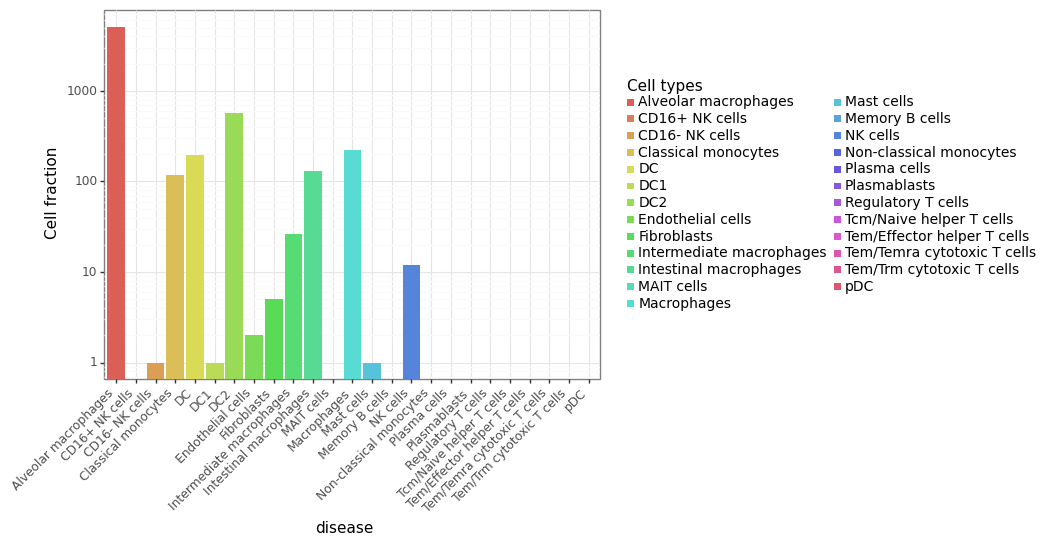

<ggplot: (8728794355965)>

In [37]:
#colopal=make_palette(n=len(np.unique(my_obs[y_obs])))

(ggplot(my_obs[my_obs.disease=="Healthy"], aes(fill=y_obs, y="size", x=y_obs)) +
    geom_bar(stat="identity") + 
    #geom_col(width = 0.4) +
    labs(x = x_axis, y = "Cell fraction", fill = "Cell types") +
    scale_y_log10() +
    #scale_fill_manual(values=colopal) +
    theme_bw() + #coord_flip() + 
    theme(axis_text_x = element_text(hjust=1, angle = 45),
         legend_key_size = 5,
         legend_text = element_text(size=10)))